# Programación Genética — Ejercicio 1
## Diseño de un circuito lógico: decodificador BCD a 7 segmentos

**Enunciado:** Utilice Programación Genética para obtener el diseño de un circuito lógico, tomando como ejemplo el codificador de 7 segmentos. Describa el conjunto de terminales, el conjunto de funciones y la función de aptitud. Use una librería de Python.

**Librería usada:** `DEAP` (Distributed Evolutionary Algorithms in Python), que incluye el módulo `gp` para Programación Genética con cromosomas tipo árbol.

---

## Planteamiento

El decodificador BCD a 7 segmentos recibe un número de 4 bits ($x_3 x_2 x_1 x_0$) que representa un dígito decimal de 0 a 9, y activa los 7 segmentos (a, b, c, d, e, f, g) de un display para dibujar ese dígito.



### Paso 1. El problema

Encontrar, para cada segmento, una expresión booleana en función de $x_3, x_2, x_1, x_0$ que reproduzca exactamente la tabla de verdad del display de 7 segmentos para los dígitos 0 a 9.

### Paso 2. Conjunto de terminales, $T$
Las hojas del árbol son las entradas del circuito y las constantes lógicas:

$$T = \{x_3,\ x_2,\ x_1,\ x_0,\ \text{True},\ \text{False}\}$$

donde $x_3$ es el bit más significativo y $x_0$ el menos significativo, de modo que el dígito es $d = 8x_3 + 4x_2 + 2x_1 + x_0$. Las constantes `True`/`False` se incluyen porque permiten al AG construir subexpresiones como una compuerta forzada a un valor fijo, lo que le da más flexibilidad.

### Paso 3. Conjunto de funciones primitivas, $F$
Los nodos internos son las compuertas lógicas disponibles:

$$F = \{\text{AND}(2),\ \text{OR}(2),\ \text{NOT}(1),\ \text{XOR}(2),\ \text{NAND}(2)\}$$

El número entre paréntesis es la **aridad** (número de parámetros) de cada función. Se cumple la **propiedad de clausura** que exige el documento: todas las funciones reciben booleanos y retornan booleanos, y todos los terminales son booleanos — por lo tanto cualquier árbol que se genere o que resulte de un cruce es sintáctica y semánticamente válido, sin necesidad de procedimientos de reparación.

### Paso 4. Medida de la aptitud
Para un segmento $s$, la aptitud de un árbol es el **número de filas de la tabla de verdad que reproduce correctamente**:

$$f_{apt}(\text{árbol}) = \sum_{d=0}^{9} \left[\ \text{árbol}(x_3,x_2,x_1,x_0) = T_{d,s}\ \right]$$

donde $T_{d,s}$ es el valor que debe tener el segmento $s$ para el dígito $d$. La aptitud máxima es **10** (circuito perfecto) y la mínima 0. Es el caso de "reconocimiento de patrones o clasificación" que menciona el Paso 4 del documento: se cuenta el número de instancias manejadas correctamente.

### Paso 5. Parámetros de control
- Tamaño de población: 500
- Generaciones: 60
- Probabilidad de cruce: 0.8
- Probabilidad de mutación: 0.25
- Selección: torneo de tamaño 5
- **Límite de profundidad: 10** — esto es clave, porque como advierte la sección 4.3.1 del documento, el cruce hace que los árboles crezcan en profundidad generación tras generación sin aportar aptitud (fenómeno de *bloat*), y puede llegar a interrumpir el programa por desbordamiento de pila.
- Se permiten hasta 6 reinicios por segmento, deteniéndose apenas se alcanza aptitud 10.

### Paso 6. Criterio de terminación y resultado
Se detiene cuando un árbol alcanza aptitud 10 (solución exacta) o al agotar las generaciones. El mejor individuo encontrado (*hall of fame*) se designa como el resultado de la corrida.


In [1]:
!pip install deap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 17.9 MB/s eta 0:00:00


In [2]:
import operator, random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, gp, algorithms

## Tabla de verdad del display de 7 segmentos

Cada fila indica qué segmentos deben encenderse (1) o apagarse (0) para dibujar cada dígito.

```
     a
   -----
 f|     |b
  |  g  |
   -----
 e|     |c
  |     |
   -----
     d
```

In [3]:
SEGMENTOS = ['a','b','c','d','e','f','g']

# Tabla de verdad: para cada digito, estado de los segmentos [a,b,c,d,e,f,g]
TABLA = {
    0: [1,1,1,1,1,1,0],
    1: [0,1,1,0,0,0,0],
    2: [1,1,0,1,1,0,1],
    3: [1,1,1,1,0,0,1],
    4: [0,1,1,0,0,1,1],
    5: [1,0,1,1,0,1,1],
    6: [1,0,1,1,1,1,1],
    7: [1,1,1,0,0,0,0],
    8: [1,1,1,1,1,1,1],
    9: [1,1,1,1,0,1,1],
}

# Entradas en binario: (x3, x2, x1, x0) con x3 el bit mas significativo
ENTRADAS = [(bool(d>>3 & 1), bool(d>>2 & 1), bool(d>>1 & 1), bool(d & 1)) for d in range(10)]

print("Dig | x3 x2 x1 x0 | " + " ".join(SEGMENTOS))
print("-"*38)
for d in range(10):
    x3,x2,x1,x0 = ENTRADAS[d]
    bits = f"{int(x3)}  {int(x2)}  {int(x1)}  {int(x0)}"
    segs = "  ".join(str(v) for v in TABLA[d])
    print(f" {d}  |  {bits}  | {segs}")

Dig | x3 x2 x1 x0 | a b c d e f g
--------------------------------------
 0  |  0  0  0  0  | 1  1  1  1  1  1  0
 1  |  0  0  0  1  | 0  1  1  0  0  0  0
 2  |  0  0  1  0  | 1  1  0  1  1  0  1
 3  |  0  0  1  1  | 1  1  1  1  0  0  1
 4  |  0  1  0  0  | 0  1  1  0  0  1  1
 5  |  0  1  0  1  | 1  0  1  1  0  1  1
 6  |  0  1  1  0  | 1  0  1  1  1  1  1
 7  |  0  1  1  1  | 1  1  1  0  0  0  0
 8  |  1  0  0  0  | 1  1  1  1  1  1  1
 9  |  1  0  0  1  | 1  1  1  1  0  1  1


## Definición del conjunto de funciones $F$ y terminales $T$

In [4]:
def nand_(a, b):
    return not (a and b)

# PrimitiveSet con 4 argumentos de entrada -> son los TERMINALES variables
pset = gp.PrimitiveSet("MAIN", 4)
pset.renameArguments(ARG0='x3', ARG1='x2', ARG2='x1', ARG3='x0')

# CONJUNTO DE FUNCIONES F (nodos internos), con su aridad
pset.addPrimitive(operator.and_, 2, name="AND")
pset.addPrimitive(operator.or_,  2, name="OR")
pset.addPrimitive(operator.not_, 1, name="NOT")
pset.addPrimitive(operator.xor,  2, name="XOR")
pset.addPrimitive(nand_,         2, name="NAND")

# TERMINALES constantes
pset.addTerminal(True)
pset.addTerminal(False)

print("Conjunto de funciones F:", [p.name for p in pset.primitives[object]])
print("Conjunto de terminales T:", [t.name if hasattr(t,'name') else t.value for t in pset.terminals[object]])

Conjunto de funciones F: ['AND', 'OR', 'NOT', 'XOR', 'NAND']
Conjunto de terminales T: ['ARG0', 'ARG1', 'ARG2', 'ARG3', 'True', 'False']


## Función de aptitud y configuración del AG

In [5]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

def evalSegmento(individuo, idx_seg, tb):
    """Aptitud = numero de filas de la tabla de verdad reproducidas correctamente (max 10)"""
    func = tb.compile(expr=individuo)
    aciertos = 0
    for d, (x3, x2, x1, x0) in enumerate(ENTRADAS):
        if bool(func(x3, x2, x1, x0)) == bool(TABLA[d][idx_seg]):
            aciertos += 1
    return (aciertos,)

def construir_toolbox(idx_seg, prof_max=10):
    tb = base.Toolbox()
    tb.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=4)
    tb.register("individual", tools.initIterate, creator.Individual, tb.expr)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("compile", gp.compile, pset=pset)
    tb.register("evaluate", evalSegmento, idx_seg=idx_seg, tb=tb)
    tb.register("select", tools.selTournament, tournsize=5)
    tb.register("mate", gp.cxOnePoint)                       # cruce: intercambio de subarboles
    tb.register("expr_mut", gp.genFull, min_=0, max_=2)
    tb.register("mutate", gp.mutUniform, expr=tb.expr_mut, pset=pset)  # mutacion: cambia un subarbol
    # Limite de profundidad para evitar el crecimiento descontrolado de los arboles (bloat)
    tb.decorate("mate",   gp.staticLimit(operator.attrgetter("height"), prof_max))
    tb.decorate("mutate", gp.staticLimit(operator.attrgetter("height"), prof_max))
    return tb

In [6]:
NPOP, NGEN, P_CRUCE, P_MUT, REINICIOS = 500, 60, 0.8, 0.25, 6

def evoluciona_segmento(idx_seg):
    mejor, mejor_apt, mejor_log = None, -1, None
    for r in range(REINICIOS):
        tb = construir_toolbox(idx_seg)
        pop = tb.population(n=NPOP)
        hof = tools.HallOfFame(1)
        st = tools.Statistics(lambda ind: ind.fitness.values)
        st.register("max", np.max)
        st.register("avg", np.mean)
        _, log = algorithms.eaSimple(pop, tb, P_CRUCE, P_MUT, NGEN,
                                     stats=st, halloffame=hof, verbose=False)
        if hof[0].fitness.values[0] > mejor_apt:
            mejor, mejor_apt, mejor_log = hof[0], hof[0].fitness.values[0], log
        if mejor_apt == 10:   # solucion exacta encontrada
            break
    return mejor, mejor_apt, mejor_log

## Corrida del AG de Programación Genética

In [7]:
random.seed(7)
np.random.seed(7)

resultados = {}
historias = {}

for i, s in enumerate(SEGMENTOS):
    arbol, apt, log = evoluciona_segmento(i)
    resultados[s] = (arbol, apt)
    historias[s] = log
    print(f"Segmento {s}: aptitud {int(apt)}/10 | nodos: {len(arbol)} | profundidad: {arbol.height}")

total = sum(apt for _, apt in resultados.values())
print(f"\nTOTAL: {int(total)}/70 salidas correctas")

Segmento a: aptitud 10/10 | nodos: 33 | profundidad: 8
Segmento b: aptitud 10/10 | nodos: 14 | profundidad: 6
Segmento c: aptitud 10/10 | nodos: 20 | profundidad: 4
Segmento d: aptitud 10/10 | nodos: 27 | profundidad: 7
Segmento e: aptitud 10/10 | nodos: 17 | profundidad: 4
Segmento f: aptitud 10/10 | nodos: 25 | profundidad: 7
Segmento g: aptitud 10/10 | nodos: 21 | profundidad: 6

TOTAL: 70/70 salidas correctas


## Expresiones booleanas encontradas

Cada árbol es, literalmente, el programa/circuito evolucionado. Estas son las expresiones en notación prefija (como las genera la PG):

In [ ]:
for s in SEGMENTOS:
    arbol, apt = resultados[s]
    print(f"--- Segmento {s} (aptitud {int(apt)}/10) ---")
    print(str(arbol))
    print()

--- Segmento a (aptitud 10/10) ---
OR(NOT(AND(NOT(x3), XOR(x0, x2))), AND(OR(x0, x1), AND(OR(x0, x1), NAND(OR(NAND(NOT(XOR(x3, False)), NOT(x1)), OR(False, NAND(x2, x3))), NAND(True, x1)))))

--- Segmento b (aptitud 10/10) ---
NAND(x2, NAND(XOR(XOR(NOT(AND(x2, True)), x2), XOR(x1, x0)), x2))

--- Segmento c (aptitud 10/10) ---
OR(NAND(OR(NOT(x2), XOR(True, x0)), NOT(OR(x2, x0))), NOT(XOR(AND(x3, x3), OR(x3, x1))))

--- Segmento d (aptitud 10/10) ---
NAND(XOR(OR(NAND(x1, x0), x3), x1), XOR(NOT(XOR(x0, x2)), OR(AND(NOT(x1), False), OR(False, XOR(OR(x1, NAND(x3, x0)), x1)))))

--- Segmento e (aptitud 10/10) ---
AND(OR(OR(x0, x1), NOT(x2)), AND(NOT(x0), OR(NAND(x0, x0), AND(x2, x1))))

--- Segmento f (aptitud 10/10) ---
NAND(NOT(NOT(True)), NAND(OR(XOR(NOT(x2), True), XOR(NAND(AND(x0, XOR(True, x3)), NOT(x2)), x1)), NAND(AND(x0, x1), x0)))

--- Segmento g (aptitud 10/10) ---
NAND(NOT(NOT(NAND(NAND(OR(x1, True), OR(x3, x0)), OR(False, x1)))), AND(NOT(XOR(x1, x2)), NOT(x3)))



## Verificación: el circuito evolucionado vs. la tabla de verdad

In [8]:
tb_aux = construir_toolbox(0)
funciones = {s: tb_aux.compile(expr=resultados[s][0]) for s in SEGMENTOS}

print("Dig | Esperado (abcdefg) | Obtenido (abcdefg) | OK")
print("-"*54)
todo_ok = True
for d in range(10):
    x3, x2, x1, x0 = ENTRADAS[d]
    obtenido = [int(bool(funciones[s](x3, x2, x1, x0))) for s in SEGMENTOS]
    esperado = TABLA[d]
    ok = obtenido == esperado
    todo_ok = todo_ok and ok
    print(f" {d}  |     {''.join(map(str,esperado))}        |     {''.join(map(str,obtenido))}        | {'SI' if ok else 'NO'}")

print(f"\nDecodificador completo correcto: {todo_ok}")

Dig | Esperado (abcdefg) | Obtenido (abcdefg) | OK
------------------------------------------------------
 0  |     1111110        |     1111110        | SI
 1  |     0110000        |     0110000        | SI
 2  |     1101101        |     1101101        | SI
 3  |     1111001        |     1111001        | SI
 4  |     0110011        |     0110011        | SI
 5  |     1011011        |     1011011        | SI
 6  |     1011111        |     1011111        | SI
 7  |     1110000        |     1110000        | SI
 8  |     1111111        |     1111111        | SI
 9  |     1111011        |     1111011        | SI

Decodificador completo correcto: True


## Visualización del display

Se dibujan los dígitos usando únicamente las salidas de los circuitos evolucionados por PG.

In [9]:
def dibuja_digito(segs):
    a,b,cc,dd,e,f,g = segs
    l = []
    l.append(" " + ("___" if a else "   ") + " ")
    l.append(("|" if f else " ") + ("___" if g else "   ") + ("|" if b else " "))
    l.append(("|" if e else " ") + ("___" if dd else "   ") + ("|" if cc else " "))
    return l

filas = [[], [], []]
for d in range(10):
    x3, x2, x1, x0 = ENTRADAS[d]
    segs = [int(bool(funciones[s](x3, x2, x1, x0))) for s in SEGMENTOS]
    lineas = dibuja_digito(segs)
    for k in range(3):
        filas[k].append(lineas[k])

for k in range(3):
    print("   ".join(filas[k]))

 ___             ___     ___             ___     ___     ___     ___     ___ 
|   |       |    ___|    ___|   |___|   |___    |___        |   |___|   |___|
|___|       |   |___     ___|       |    ___|   |___|       |   |___|    ___|


## Convergencia del algoritmo

Historia de la aptitud del mejor individuo y de la aptitud promedio de la población, para la última corrida de cada segmento (equivalente a la figura 4.12 del documento).

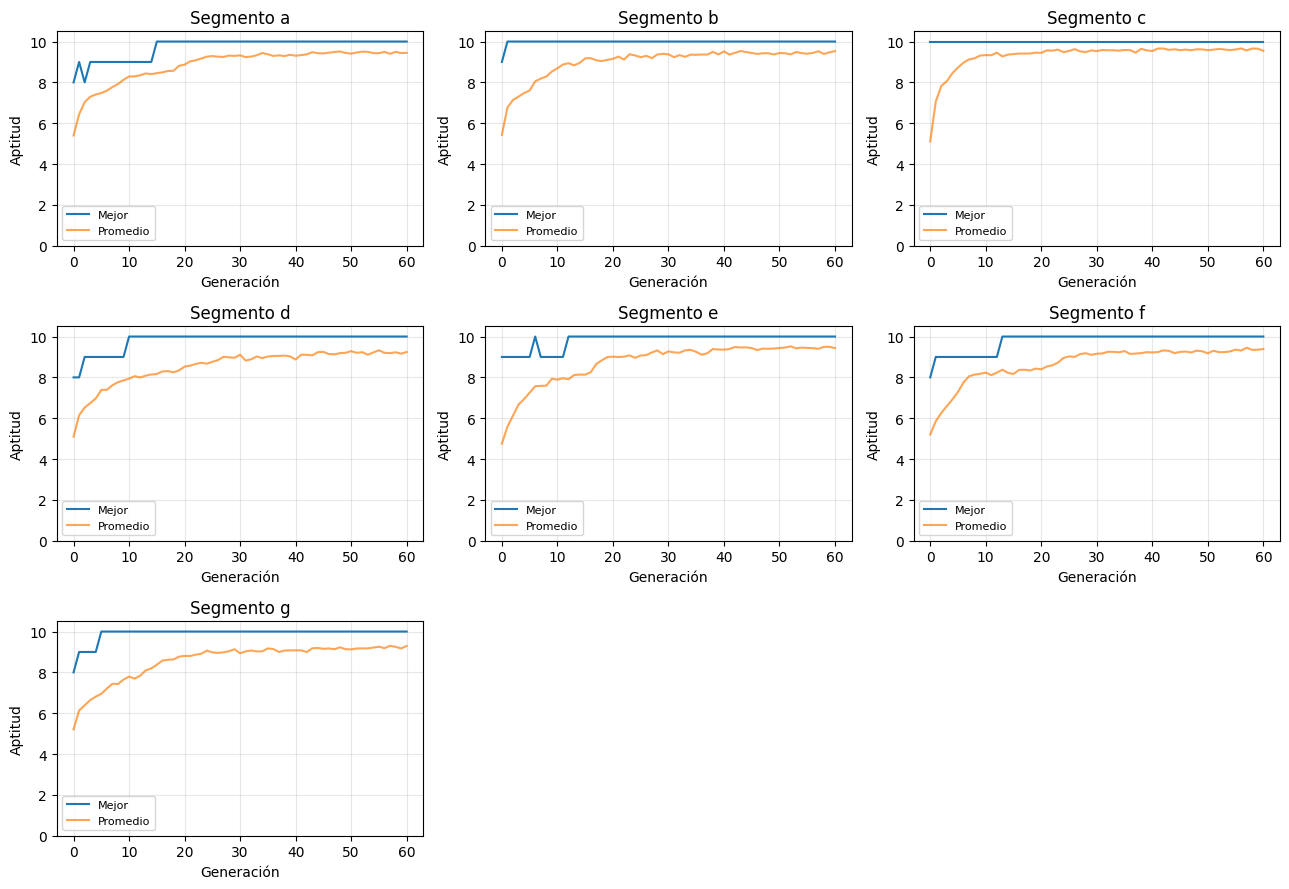

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
axes = axes.flatten()

for i, s in enumerate(SEGMENTOS):
    log = historias[s]
    gens = log.select("gen")
    axes[i].plot(gens, log.select("max"), label="Mejor")
    axes[i].plot(gens, log.select("avg"), label="Promedio", alpha=0.7)
    axes[i].set_title(f"Segmento {s}")
    axes[i].set_xlabel("Generación")
    axes[i].set_ylabel("Aptitud")
    axes[i].set_ylim(0, 10.5)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

for j in range(len(SEGMENTOS), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Estructura de árbol de una solución

Se muestra el árbol del segmento con la expresión más compacta, para ver la estructura típica de un cromosoma de PG: nodos internos = funciones, hojas = terminales.

In [ ]:
seg_compacto = min(SEGMENTOS, key=lambda s: len(resultados[s][0]))
arbol = resultados[seg_compacto][0]

print(f"Segmento más compacto: {seg_compacto} ({len(arbol)} nodos, profundidad {arbol.height})\n")
print("Expresión:", str(arbol), "\n")

def imprime_arbol(arbol, idx=0, nivel=0):
    """Recorrido en PREORDEN del árbol (raíz, subárbol izq, subárbol der)"""
    nodo = arbol[idx]
    nombre = nodo.name if hasattr(nodo, 'name') else str(nodo.value)
    tipo = "FUNC" if nodo.arity > 0 else "TERM"
    print("   "*nivel + f"└─ {nombre}  [{tipo}]")
    hijo = idx + 1
    for _ in range(nodo.arity):
        hijo = imprime_arbol(arbol, hijo, nivel+1)
    return hijo

imprime_arbol(arbol)

Segmento más compacto: b (14 nodos, profundidad 6)

Expresión: NAND(x2, NAND(XOR(XOR(NOT(AND(x2, True)), x2), XOR(x1, x0)), x2)) 

└─ NAND  [FUNC]
   └─ ARG1  [TERM]
   └─ NAND  [FUNC]
      └─ XOR  [FUNC]
         └─ XOR  [FUNC]
            └─ NOT  [FUNC]
               └─ AND  [FUNC]
                  └─ ARG1  [TERM]
                  └─ True  [TERM]
            └─ ARG1  [TERM]
         └─ XOR  [FUNC]
            └─ ARG2  [TERM]
            └─ ARG3  [TERM]
      └─ ARG1  [TERM]


14

## Conclusiones

1. **La PG encontró el circuito sin que se le dijera cómo.** Solo se le dio la tabla de verdad (la aptitud) y las compuertas disponibles (el conjunto de funciones). El AG no recibió ninguna información sobre álgebra de Boole, mapas de Karnaugh ni simplificación de expresiones; la solución emergió de la evolución. Esto responde directamente a la pregunta central que plantea la sección 4.2 del documento: *cómo hacer que los computadores resuelvan problemas sin programarlos explícitamente*.

2. **El genotipo es el fenotipo.** A diferencia de los Algoritmos Genéticos del capítulo anterior — donde el cromosoma binario debía decodificarse a un valor real — aquí el árbol *es* el circuito. No hay decodificación: se ejecuta directamente para medir su aptitud.

3. **La clausura simplificó el diseño.** Como todas las funciones y terminales son booleanos, cualquier cruce de subárboles produce un circuito válido. No hubo necesidad de procedimientos de reparación.

4. **Las soluciones no son las mínimas.** Los circuitos obtenidos son correctos pero contienen redundancias (expresiones como `NOT(NOT(x))` o ramas que siempre evalúan a una constante). La PG optimiza la aptitud, no la elegancia: si se quisiera el circuito mínimo habría que añadir a la función de aptitud una penalización por número de nodos, convirtiéndolo en un problema multi-objetivo.

5. **El control del crecimiento fue necesario.** Sin el límite de profundidad los árboles crecen indefinidamente (*bloat*), consumiendo memoria sin mejorar la aptitud — exactamente lo que advierte la sección 4.3.1 del documento.
